# Zadanie 3 - Analiza ofert mieszkań w Warszawie

## Część 1 - Wstępna eksploracja (2 pkt)

Wczytanie zbioru `mieszkania_warszawa.csv` do `DataFrame` oraz wstępna ocena danych:
`shape`, `info()`, `describe()`, `isnull().sum()`, wraz z komentarzem do podejrzanych
wartości w statystykach opisowych.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("mieszkania_warszawa.csv")
print("Kształt (shape):", df.shape)
df.head(10)

Kształt (shape): (2000, 10)


,id_oferty,dzielnica,metraz_m2,liczba_pokoi,pietro,rok_budowy,ma_balkon,ma_miejsce_parkingowe,odleglosc_od_centrum_km,cena_pln
0,10001,Białołęka,69.1,4,3,1995,True,False,4.52,948319.0
1,10002,Praga-Południe,29.9,1,4,2016,True,False,2.13,408287.0
2,10003,Wilanów,90.9,5,4,2005,True,True,14.62,1464602.0
3,10004,Targówek,29.8,2,3,2016,False,False,0.50,390717.0
4,10005,Ursynów,61.7,2,7,1997,True,False,6.38,764932.0
5,10006,Białołęka,38.4,3,6,1966,True,True,5.58,427097.0
6,10007,Ochota,53.6,3,8,1952,True,False,5.67,554464.0
7,10008,Śródmieście,62.2,3,6,1984,True,True,10.34,1175695.0
8,10009,Białołęka,62.1,3,9,2009,False,False,2.40,995279.0
9,10010,Wilanów,64.3,4,0,2014,True,False,2.30,1348134.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   object 
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), object(1)
memory usage: 129.0+ KB


In [31]:
# Statystyki opisowe kolumn liczbowych (transpozycja dla czytelności min/max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_oferty,2000.0,11000.500000,577.494589,10001.000000,10500.75,11000.50,1.150025e+04,1.200000e+04
metraz_m2,2000.0,56.965758,30.787760,18.000000,40.80,55.35,6.990000e+01,5.851873e+02
liczba_pokoi,2000.0,3.085500,1.264907,1.000000,2.00,3.00,4.000000e+00,6.000000e+00
pietro,2000.0,5.415500,3.501998,0.000000,2.00,5.00,8.000000e+00,1.100000e+01
rok_budowy,2000.0,1993.889500,21.076632,1800.000000,1979.00,1997.00,2.011000e+03,2.050000e+03
odleglosc_od_centrum_km,2000.0,6.222265,3.909166,0.500000,3.35,5.55,8.322500e+00,2.500000e+01
cena_pln,2000.0,880961.205231,749976.280154,61776.324651,568512.00,809575.50,1.070190e+06,2.292390e+07


In [32]:
# Pełny obraz - również kolumny tekstowe i logiczne
df.describe(include="all")

,id_oferty,dzielnica,metraz_m2,liczba_pokoi,pietro,rok_budowy,ma_balkon,ma_miejsce_parkingowe,odleglosc_od_centrum_km,cena_pln
count,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000,2000.000000,2.000000e+03
unique,NaN,11,NaN,NaN,NaN,NaN,2,2,NaN,NaN
top,NaN,Mokotów,NaN,NaN,NaN,NaN,True,False,NaN,NaN
freq,NaN,210,NaN,NaN,NaN,NaN,1482,1074,NaN,NaN
mean,11000.500000,NaN,56.965758,3.085500,5.415500,1993.889500,NaN,NaN,6.222265,8.809612e+05
std,577.494589,NaN,30.787760,1.264907,3.501998,21.076632,NaN,NaN,3.909166,7.499763e+05
min,10001.000000,NaN,18.000000,1.000000,0.000000,1800.000000,NaN,NaN,0.500000,6.177632e+04
25%,10500.750000,NaN,40.800000,2.000000,2.000000,1979.000000,NaN,NaN,3.350000,5.685120e+05
50%,11000.500000,NaN,55.350000,3.000000,5.000000,1997.000000,NaN,NaN,5.550000,8.095755e+05
75%,11500.250000,NaN,69.900000,4.000000,8.000000,2011.000000,NaN,NaN,8.322500,1.070190e+06


In [33]:
# Braki danych w poszczególnych kolumnach
df.isnull().sum()

id_oferty                  0
dzielnica                  0
metraz_m2                  0
liczba_pokoi               0
pietro                     0
rok_budowy                 0
ma_balkon                  0
ma_miejsce_parkingowe      0
odleglosc_od_centrum_km    0
cena_pln                   0
dtype: int64

In [34]:
# Szybka weryfikacja podejrzanych wartości widocznych w describe()
print("rok_budowy   min/max:", df["rok_budowy"].min(), "/", df["rok_budowy"].max())
print("  - oferty z rokiem budowy > 2026 (przyszłość):", (df["rok_budowy"] > 2026).sum())
print("metraz_m2    min/max:", df["metraz_m2"].min(), "/", round(df["metraz_m2"].max(), 1))
print("  - oferty z metrażem > 200 m²:", (df["metraz_m2"] > 200).sum())
print("cena_pln     min/max:", round(df["cena_pln"].min()), "/", round(df["cena_pln"].max()))
print("  - oferty z ceną > 5 mln zł:", (df["cena_pln"] > 5_000_000).sum())
print("pietro       min/max:", df["pietro"].min(), "/", df["pietro"].max())
print("liczba_pokoi unikalne:", sorted(df["liczba_pokoi"].unique()))

rok_budowy   min/max: 1800 / 2050
  - oferty z rokiem budowy > 2026 (przyszłość): 2
metraz_m2    min/max: 18.0 / 585.2
  - oferty z metrażem > 200 m²: 5
cena_pln     min/max: 61776 / 22923902
  - oferty z ceną > 5 mln zł: 7
pietro       min/max: 0 / 11
liczba_pokoi unikalne: [1, 2, 3, 4, 5, 6]


### Co już teraz wygląda podejrzanie?

Mimo że `isnull().sum()` **nie pokazuje żadnych braków**, statystyki opisowe ujawniają
kilka **nielogicznych wartości** (prawdopodobne błędy lub wartości odstające):

1. **`rok_budowy` - `max = 2050`** → rok budowy w przyszłości (dziś mamy rok 2026), co jest
   niemożliwe. Z kolei `min = 1800` to bardzo stara zabudowa jak na ten rynek - możliwe
   błędne wpisy.
2. **`metraz_m2` - `max ≈ 585 m²`** → ekstremalnie duże mieszkanie przy medianie ok. 55 m²
   i 99. centylu ok. 109 m². Wyraźny outlier (lub błąd wpisu).
3. **`cena_pln` - `max ≈ 22,9 mln zł`** przy medianie ok. 810 tys. zł → bardzo silne wartości
   odstające; jednocześnie `min ≈ 62 tys. zł` jest podejrzanie niska jak na Warszawę.
   Średnia (≈ 881 tys.) > mediana (≈ 810 tys.) + ogromne `std` → rozkład **silnie prawoskośny**.

**Wniosek:** brak braków danych, ale są **wartości nielogiczne i odstające**
(`rok_budowy`, `metraz_m2`, `cena_pln`) do oczyszczenia w dalszych częściach.

## Część 2 - Statystyki opisowe (3 pkt)

**2.1.** `cena_pln` - średnia, mediana, odchylenie standardowe, skośność, kurtoza.

In [35]:
cena = df["cena_pln"]
print("Statystyki opisowe cena_pln:")
print(f"  średnia  (mean)     : {cena.mean():>14,.2f} zł")
print(f"  mediana  (median)   : {cena.median():>14,.2f} zł")
print(f"  odch.std (std)      : {cena.std():>14,.2f} zł")
print(f"  skośność (skewness) : {cena.skew():>14.3f}")
print(f"  kurtoza  (kurtosis) : {cena.kurt():>14.3f}")

Statystyki opisowe cena_pln:
  średnia  (mean)     :     880,961.21 zł
  mediana  (median)   :     809,575.50 zł
  odch.std (std)      :     749,976.28 zł
  skośność (skewness) :         15.858
  kurtoza  (kurtosis) :        404.218


**Co skewness mówi o kształcie rozkładu?**

Skośność (skewness) ≈ **15,9** jest zdecydowanie większa od 0, więc rozkład cen jest
**silnie prawoskośny (prawostronny)**:

- większość mieszkań ma ceny skupione wokół mediany (~810 tys. zł), ale rozkład ma długi
  **„ogon" w prawo** - nieliczne bardzo drogie oferty (do ~22,9 mln zł),
- te drogie wartości **ciągną średnią w górę**, dlatego średnia (≈ 881 tys.) jest wyższa od
  mediany (≈ 810 tys.) - to typowy objaw prawoskośności,
- kurtoza ≈ **404** (rozkład silnie **leptokurtyczny**, bardzo „ciężkie ogony") potwierdza
  obecność ekstremalnych wartości odstających.

Tak duża skośność sugeruje, że dla modelowania warto rozważyć **transformację logarytmiczną**
ceny (wykonana w Części 6).

**2.2.** `metraz_m2` - Q1, Q3 oraz IQR.

In [36]:
q1, q3 = df["metraz_m2"].quantile([0.25, 0.75])
iqr = q3 - q1
print(f"metraz_m2 - Q1 (25%): {q1:.2f} m²")
print(f"metraz_m2 - Q3 (75%): {q3:.2f} m²")
print(f"metraz_m2 - IQR     : {iqr:.2f} m²")

metraz_m2 - Q1 (25%): 40.80 m²
metraz_m2 - Q3 (75%): 69.90 m²
metraz_m2 - IQR     : 29.10 m²


**2.3.** Liczba unikalnych dzielnic oraz liczba ofert na dzielnicę.

In [37]:
print("Liczba unikalnych dzielnic:", df["dzielnica"].nunique())
print("\nLiczba ofert na dzielnicę:")
df["dzielnica"].value_counts()

Liczba unikalnych dzielnic: 11

Liczba ofert na dzielnicę:


dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64

## Część 3 - Analiza pojedynczych zmiennych (3 pkt)

**3.1.** Histogram + KDE dla `cena_pln` i `metraz_m2`.

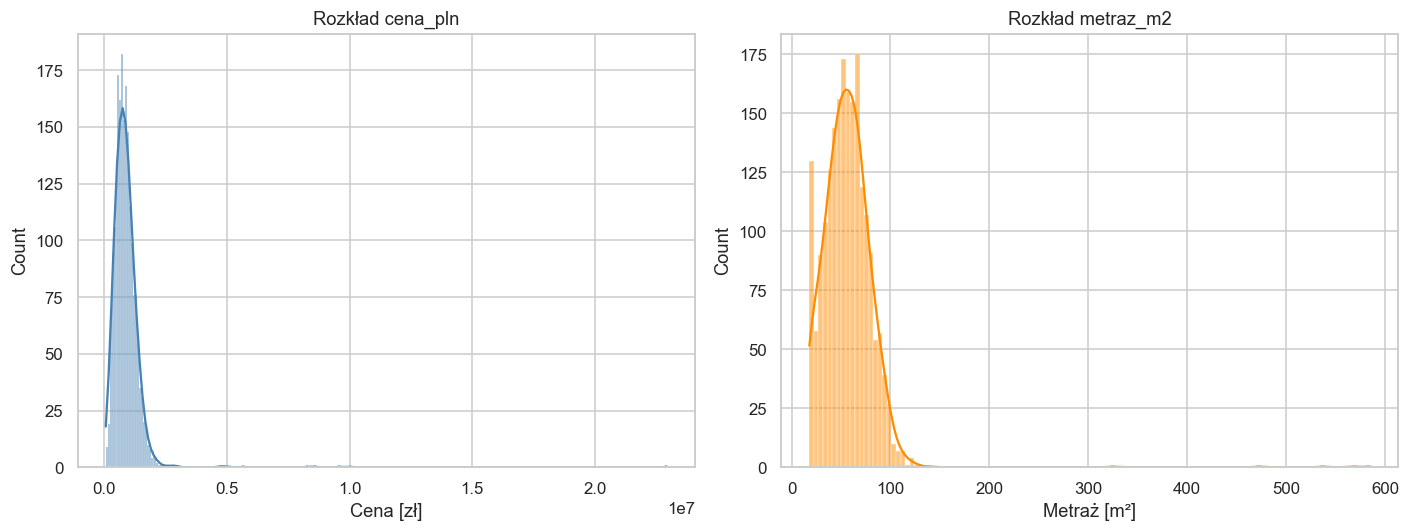

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["cena_pln"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Rozkład cena_pln")
axes[0].set_xlabel("Cena [zł]")
sns.histplot(df["metraz_m2"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Rozkład metraz_m2")
axes[1].set_xlabel("Metraż [m²]")
plt.tight_layout()
plt.show()

**Czy widać skośność?** Tak - oba rozkłady są wyraźnie **prawoskośne**: masa obserwacji
znajduje się po lewej stronie, a w prawo ciągnie się długi ogon. W `cena_pln` ogon tworzą
pojedyncze bardzo drogie oferty, w `metraz_m2` - kilka bardzo dużych mieszkań. Potwierdza to
dodatnią skośność policzoną w Części 2.

**3.2.** Boxplot dla `cena_pln`.

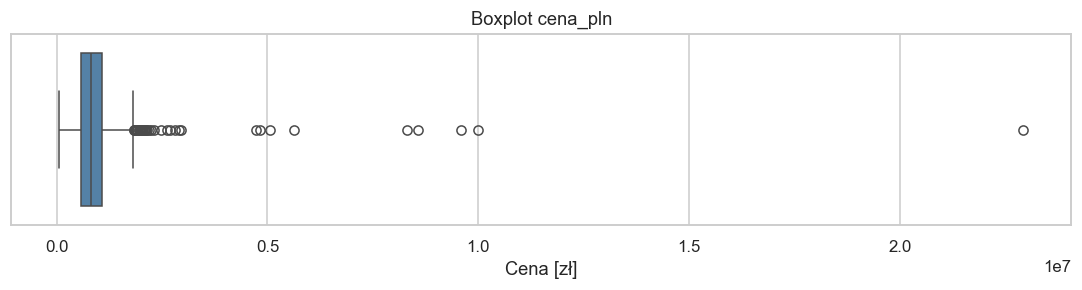

In [39]:
fig, ax = plt.subplots(figsize=(10, 2.8))
sns.boxplot(x=df["cena_pln"], ax=ax, color="steelblue")
ax.set_title("Boxplot cena_pln")
ax.set_xlabel("Cena [zł]")
plt.tight_layout()
plt.show()

**Co widać na boxplocie?** Pudełko (zakres IQR, ok. 0,57–1,07 mln zł) jest skupione nisko,
mediana ~810 tys. zł. Po prawej stronie widać **liczne punkty powyżej górnego wąsa** - to
wartości odstające (drogie oferty), sięgające aż ~22,9 mln zł. Dolny wąs jest krótki (brak
skrajnie tanich mieszkań). Obraz jednoznacznie potwierdza **prawoskośność** i obecność
outlierów cenowych.

**3.3.** Countplot - liczba ofert w każdej dzielnicy (malejąco).

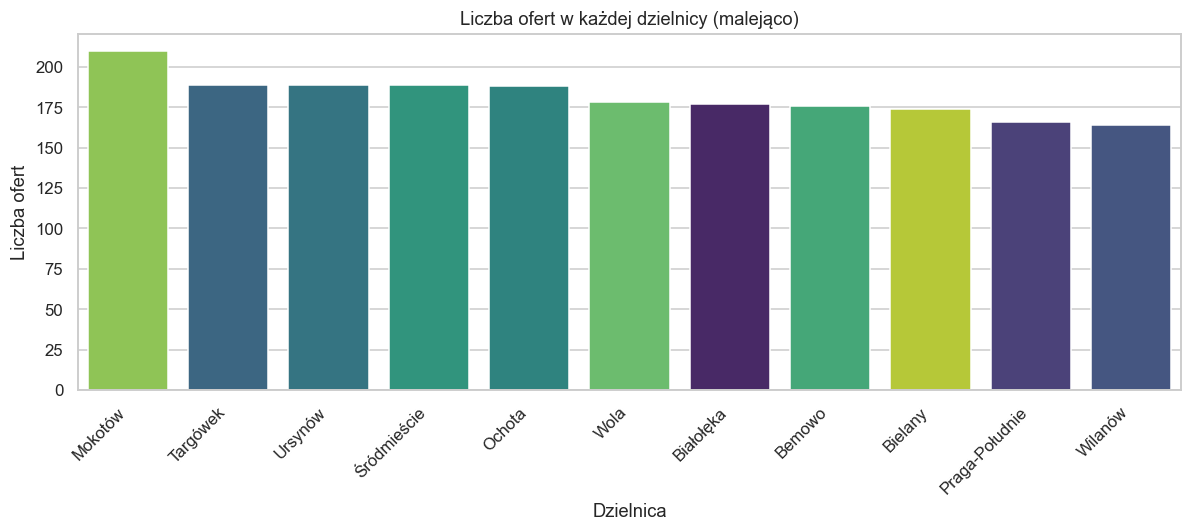

In [40]:
kolejnosc = df["dzielnica"].value_counts().index
fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(data=df, x="dzielnica", order=kolejnosc,
              hue="dzielnica", palette="viridis", legend=False, ax=ax)
ax.set_title("Liczba ofert w każdej dzielnicy (malejąco)")
ax.set_xlabel("Dzielnica")
ax.set_ylabel("Liczba ofert")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Część 4 - Analiza zależności (3 pkt)

**4.1.** Heatmapa macierzy korelacji zmiennych numerycznych.

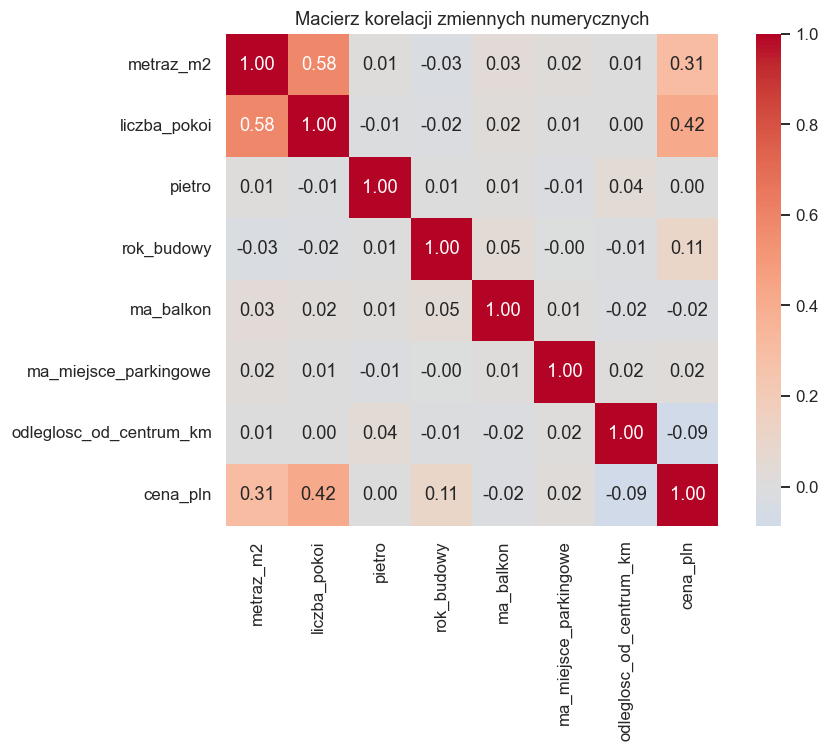

Korelacja z cena_pln (malejąco):
cena_pln                   1.000
liczba_pokoi               0.419
metraz_m2                  0.310
rok_budowy                 0.106
ma_miejsce_parkingowe      0.018
pietro                     0.004
ma_balkon                 -0.017
odleglosc_od_centrum_km   -0.086
Name: cena_pln, dtype: float64


In [41]:
# bool -> int, bo pandas nie liczy korelacji dla kolumn typu bool
df_corr = df.copy()
df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)
corr = df_corr.select_dtypes(include="number").drop(columns=["id_oferty"]).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Macierz korelacji zmiennych numerycznych")
plt.tight_layout()
plt.show()

print("Korelacja z cena_pln (malejąco):")
print(corr["cena_pln"].sort_values(ascending=False).round(3))

**Która zmienna najsilniej koreluje z ceną?** Najwyższą korelację z `cena_pln` ma
**`liczba_pokoi` (r ≈ 0,42)**, a tuż za nią `metraz_m2` (r ≈ 0,31). Co ciekawe, metraż -
który intuicyjnie powinien być najsilniejszym predyktorem - wypada słabiej, ponieważ jego
korelację **psują wartości odstające** (mieszkania 400–585 m² z nietypowymi cenami).
Pozostałe zmienne (`pietro`, `ma_balkon`, `ma_miejsce_parkingowe`, `odleglosc_od_centrum_km`)
mają korelacje bliskie 0.

**4.2.** Scatter plot `metraz_m2` vs `cena_pln` (kolor = dzielnica).

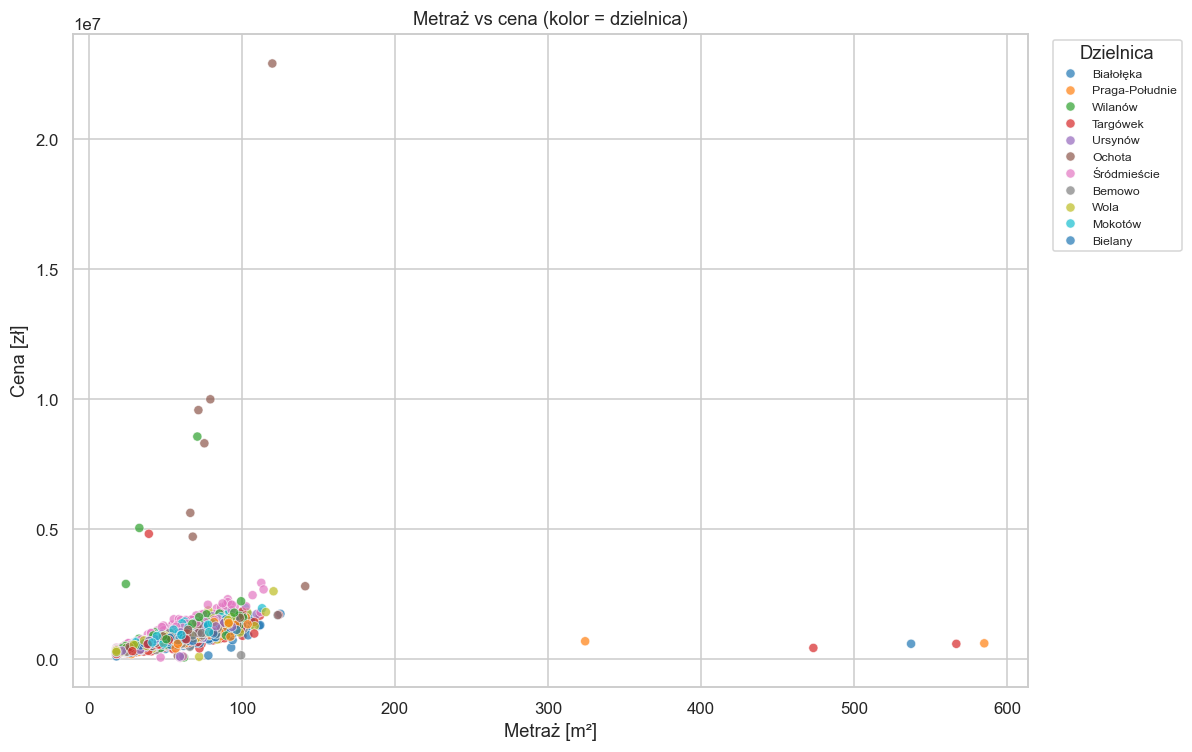

In [42]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=df, x="metraz_m2", y="cena_pln", hue="dzielnica",
                palette="tab10", alpha=0.7, ax=ax)
ax.set_title("Metraż vs cena (kolor = dzielnica)")
ax.set_xlabel("Metraż [m²]")
ax.set_ylabel("Cena [zł]")
ax.legend(title="Dzielnica", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**4.3.** Boxplot ceny za m² (`cena_pln / metraz_m2`) w podziale na dzielnice.

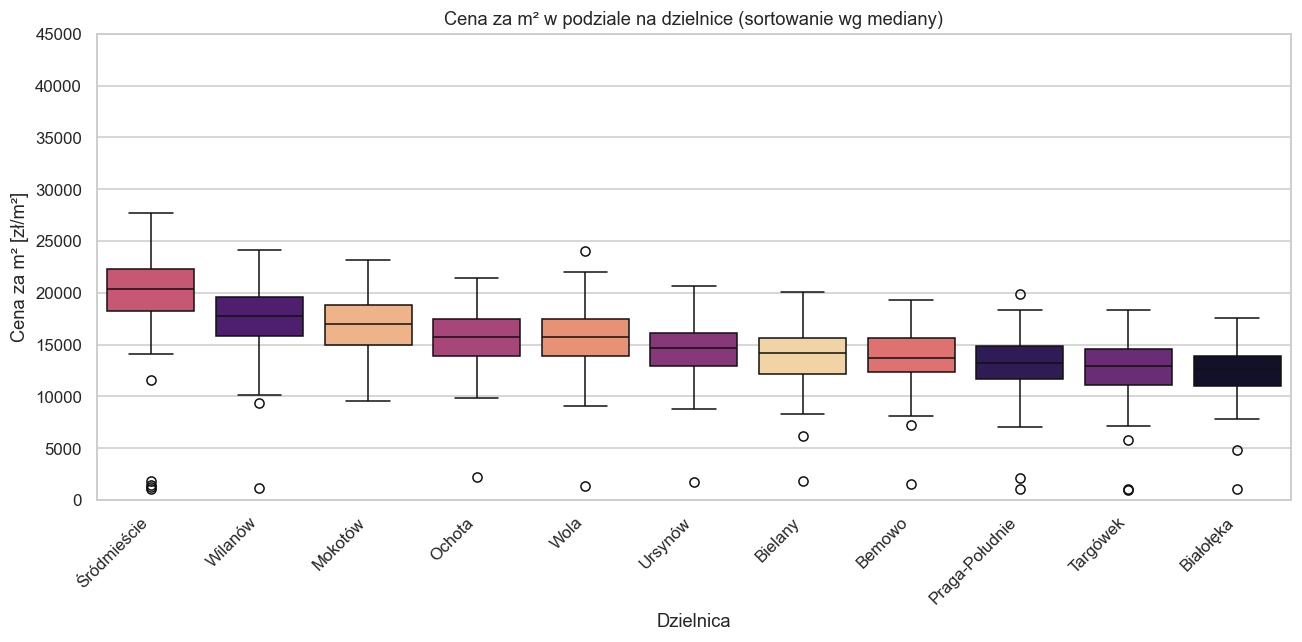

Mediana ceny za m² wg dzielnic:
dzielnica
Śródmieście       20364.0
Wilanów           17761.0
Mokotów           16958.0
Ochota            15770.0
Wola              15769.0
Ursynów           14682.0
Bielany           14235.0
Bemowo            13710.0
Praga-Południe    13262.0
Targówek          12975.0
Białołęka         12599.0
Name: cena_pln_per_m2, dtype: float64


In [43]:
# Cena za metr kwadratowy - przyda się też dalej
df["cena_pln_per_m2"] = df["cena_pln"] / df["metraz_m2"]

kolejnosc_m2 = (df.groupby("dzielnica")["cena_pln_per_m2"]
                  .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=kolejnosc_m2,
            hue="dzielnica", palette="magma", legend=False, ax=ax)
ax.set_title("Cena za m² w podziale na dzielnice (sortowanie wg mediany)")
ax.set_xlabel("Dzielnica")
ax.set_ylabel("Cena za m² [zł/m²]")
ax.set_ylim(0, 45000)  # przycięcie skali dla czytelności (pojedyncze outliery > 45 tys.)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mediana ceny za m² wg dzielnic:")
print(df.groupby("dzielnica")["cena_pln_per_m2"].median().sort_values(ascending=False).round(0))

**Która dzielnica ma najwyższe ceny za m²?** Najdroższe **`Śródmieście`** (mediana
~20,4 tys. zł/m²), dalej `Wilanów` (~17,8 tys.) i `Mokotów` (~17,0 tys.). Najtańsze są
`Białołęka` (~12,6 tys.) i `Targówek` (~13,0 tys.). Wynik zgodny z intuicją - centrum i
prestiżowe dzielnice są najdroższe.

## Część 5 - Detekcja outlierów (4 pkt)

**5.1.** Outliery w `cena_pln` trzema metodami: IQR (1.5×), Z-score (|z|>3), Modified Z-score (|z_mod|>3.5).

In [44]:
cena = df["cena_pln"]

# 1) Metoda IQR (1.5 x)
q1, q3 = cena.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out_iqr = (cena < low) | (cena > high)

# 2) Z-score (|z| > 3)
z = (cena - cena.mean()) / cena.std()
out_z = z.abs() > 3

# 3) Modified Z-score (|z_mod| > 3.5), oparty na medianie i MAD
med = cena.median()
mad = (cena - med).abs().median()
z_mod = 0.6745 * (cena - med) / mad
out_mz = z_mod.abs() > 3.5

print(f"IQR (1.5x)         : {out_iqr.sum():>3} outlierów   (granice: {low:,.0f} – {high:,.0f} zł)")
print(f"Z-score (|z|>3)    : {out_z.sum():>3} outlierów")
print(f"Modified Z (>3.5)  : {out_mz.sum():>3} outlierów")

IQR (1.5x)         :  39 outlierów   (granice: -184,005 – 1,822,707 zł)
Z-score (|z|>3)    :   9 outlierów
Modified Z (>3.5)  :  22 outlierów


Trzy metody dają **różne wyniki** (IQR: 39 > Modified Z: 22 > Z-score: 9). Klasyczny Z-score
wykrywa najmniej, ponieważ średnia i odchylenie standardowe są **same zaburzone** przez
ekstremalne wartości - dlatego odporniejszy Modified Z-score (oparty na medianie/MAD) oraz
metoda IQR znajdują ich więcej.

**5.2.** Outliery w `metraz_m2` metodą IQR + top 5 największych wartości.

In [45]:
q1m, q3m = df["metraz_m2"].quantile([0.25, 0.75])
iqrm = q3m - q1m
low_m, high_m = q1m - 1.5 * iqrm, q3m + 1.5 * iqrm
out_metraz = df[(df["metraz_m2"] < low_m) | (df["metraz_m2"] > high_m)]

print(f"Outliery metraz_m2 (IQR): {len(out_metraz)}   (granice: {low_m:.1f} – {high_m:.1f} m²)")
print("\nTop 5 największych metraży:")
df.nlargest(5, "metraz_m2")[["id_oferty", "dzielnica", "metraz_m2", "liczba_pokoi", "cena_pln"]]

Outliery metraz_m2 (IQR): 13   (granice: -2.9 – 113.6 m²)

Top 5 największych metraży:


,id_oferty,dzielnica,metraz_m2,liczba_pokoi,cena_pln
1597,11598,Praga-Południe,585.187341,3,614202.0
1845,11846,Targówek,566.921693,3,593446.0
53,10054,Białołęka,537.356930,2,595626.0
1681,11682,Targówek,473.491995,1,436705.0
1050,11051,Praga-Południe,324.358377,2,693470.0


**5.3.** Wiersze z bzdurnymi wartościami w `rok_budowy` (przed 1900 lub po 2026).

In [46]:
bzdury = df[(df["rok_budowy"] < 1900) | (df["rok_budowy"] > 2026)]
print(f"Wiersze z nielogicznym rok_budowy: {len(bzdury)}")
bzdury[["id_oferty", "dzielnica", "rok_budowy", "metraz_m2", "cena_pln"]]

Wiersze z nielogicznym rok_budowy: 5


,id_oferty,dzielnica,rok_budowy,metraz_m2,cena_pln
237,10238,Targówek,1850,59.0,660629.0
557,10558,Ursynów,2050,45.5,568546.0
635,10636,Praga-Południe,1800,76.0,1323289.0
1030,11031,Praga-Południe,2050,55.5,723745.0
1954,11955,Wilanów,1800,72.1,1624939.0


## Część 6 - Decyzja i czyszczenie (2 pkt)

**6.1.** Usunięcie wierszy z nielogicznym `rok_budowy`.

In [47]:
przed = len(df)
df = df[(df["rok_budowy"] >= 1900) & (df["rok_budowy"] <= 2026)].reset_index(drop=True)
print(f"Usunięto {przed - len(df)} wierszy z nielogicznym rok_budowy. Pozostało {len(df)}.")

Usunięto 5 wierszy z nielogicznym rok_budowy. Pozostało 1995.


**6.2.** Winsoryzacja `cena_pln` (cap na 1. i 99. percentylu) → kolumna `cena_pln_capped`.

In [48]:
p1, p99 = df["cena_pln"].quantile([0.01, 0.99])
df["cena_pln_capped"] = df["cena_pln"].clip(lower=p1, upper=p99)

print(f"Winsoryzacja - cap na p1 = {p1:,.0f} zł oraz p99 = {p99:,.0f} zł")
print(df[["cena_pln", "cena_pln_capped"]].describe().round(0))

Winsoryzacja - cap na p1 = 199,598 zł oraz p99 = 2,101,934 zł
         cena_pln  cena_pln_capped
count      1995.0           1995.0
mean     880712.0         848710.0
std      750609.0         381632.0
min       61776.0         199598.0
25%      567814.0         567814.0
50%      809594.0         809594.0
75%     1069436.0        1069436.0
max    22923902.0        2101934.0


**6.3.** Kolumna `cena_pln_log = log1p(cena_pln)` - porównanie skośności i histogramy.

Skewness przed (cena_pln)     : 15.858
Skewness po   (log1p)         : -0.241


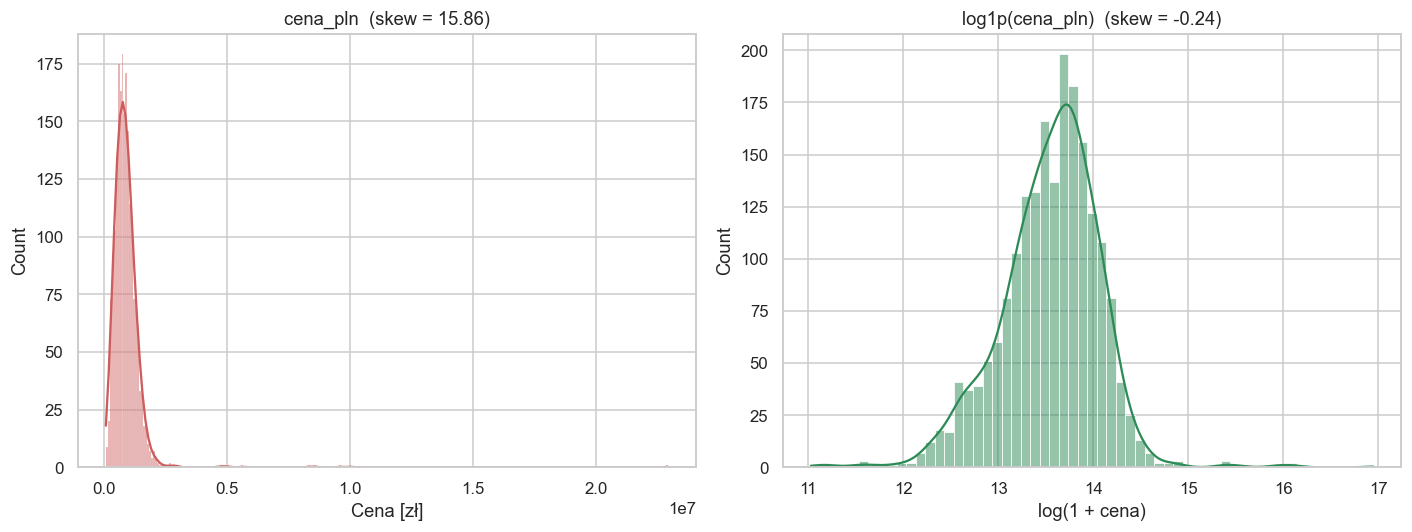

In [49]:
df["cena_pln_log"] = np.log1p(df["cena_pln"])

skew_przed = df["cena_pln"].skew()
skew_po = df["cena_pln_log"].skew()
print(f"Skewness przed (cena_pln)     : {skew_przed:.3f}")
print(f"Skewness po   (log1p)         : {skew_po:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["cena_pln"], kde=True, ax=axes[0], color="indianred")
axes[0].set_title(f"cena_pln  (skew = {skew_przed:.2f})")
axes[0].set_xlabel("Cena [zł]")
sns.histplot(df["cena_pln_log"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(cena_pln)  (skew = {skew_po:.2f})")
axes[1].set_xlabel("log(1 + cena)")
plt.tight_layout()
plt.show()

Transformacja logarytmiczna **praktycznie usuwa skośność**: z ≈ 15,9 (silnie prawoskośny)
do ≈ −0,24 (rozkład niemal symetryczny). Po lewej histogram surowy jest ściśnięty przy zerze
z długim ogonem, po prawej `log1p` daje kształt zbliżony do rozkładu normalnego - znacznie
lepszy do modeli statystycznych zakładających normalność.

## Część 7 - Wnioski (1 pkt)

**Najważniejsze wnioski z analizy rynku mieszkań w Warszawie:**

1. **Rozkład cen jest silnie prawoskośny** (skewness ≈ 15,9). Typowe mieszkanie kosztuje
   ok. 810 tys. zł (mediana), a połowa ofert mieści się w przedziale ~0,57–1,07 mln zł (IQR).
   Pojedyncze oferty luksusowe (do ~22,9 mln zł) zawyżają średnią - **mediana lepiej opisuje
   „typowe" mieszkanie** niż średnia.

2. **Cena zależy głównie od wielkości mieszkania** - najsilniej koreluje z `liczba_pokoi`
   (r ≈ 0,42) i `metraz_m2` (r ≈ 0,31). Cechy takie jak piętro, balkon, miejsce parkingowe
   czy odległość od centrum mają **znikomy wpływ** na cenę całkowitą.

3. **Lokalizacja decyduje o cenie za m²**: najdroższe jest `Śródmieście` (~20,4 tys. zł/m²),
   a następnie `Wilanów` i `Mokotów`; najtańsze `Białołęka` i `Targówek` (~12–13 tys. zł/m²).
   Cena za m² to lepszy wskaźnik porównawczy niż cena całkowita.

4. **Dane wymagały czyszczenia** - wykryto outliery cenowe (IQR: 39, Modified Z: 22, Z-score:
   9), ekstremalne metraże (do 585 m²) oraz 5 wierszy z **niemożliwym `rok_budowy`** (1800,
   1850, 2050). Różne metody detekcji dają różne liczby - klasyczny Z-score jest najmniej
   czuły, bo sam jest zaburzany przez wartości odstające.

5. **Transformacja logarytmiczna `log1p` normalizuje rozkład cen** (skewness 15,9 → −0,24),
   co czyni zmienną odpowiednią do dalszego modelowania. W praktyce do analiz warto używać
   `cena_pln_capped` (po winsoryzacji) lub `cena_pln_log` zamiast surowej ceny.